In [8]:
import shutil

print(shutil.which("ffmpeg"))

/opt/homebrew/bin/ffmpeg


In [10]:
import os

print(os.getcwd())

/Users/dudureale/IbmecPriv/Ibmec/ExtracaoDeDados/ac14


In [11]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.lower().endswith(".mp3"):
            print(os.path.abspath(os.path.join(root, file)))

In [13]:
%pip install git+https://github.com/openai/whisper.git

import whisper

# Carrega o modelo 'tiny' do Whisper para uma transcrição mais rápida
model = whisper.load_model('tiny')

# Caminho do arquivo de áudio
audio_path = "entrevista-pedro-calais-98news-26-06-2025.mp3"

# Realiza a transcrição
result = model.transcribe(audio_path)

# Exibe o texto transcrito
print(result['text'])



  Cloning https://github.com/openai/whisper.git to /private/var/folders/34/wm2jgwcx3m95w1yv3b5vjh4m0000gn/T/pip-req-build-rtx20m7g
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /private/var/folders/34/wm2jgwcx3m95w1yv3b5vjh4m0000gn/T/pip-req-build-rtx20m7g
  Resolved https://github.com/openai/whisper.git to commit 86098128c0b4f24f0e2aa2994de830614b474227
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


/Users/dudureale/IbmecPriv/Ibmec/ExtracaoDeDados/.venv/lib/python3.14/site-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 A chegada de tecnologias transformadoras como a inteligência artificial tem desafiado empresas a repensar em seus modelos de capacitação e gestão. Embora a adossão da IA avance ainda há um descompasse o entre a velocidade de essa evolução e a preparação dos profissionais para lidar com ela de forma estratégica. Para entender melhor esse cenário, a gente conversa com um Pedro Calais do autor em ciência da computação, professor e pesquisador em ciências de dados no e-bimec, Pedro Obrigado por começar com a gente. O Brasil é o Pedro, algum tema interessante abordar, a primeira relação a questão humana, ocupação, subituição. Você acha que AIA vai acabar com os empregos? Olha, essa pergunta muito relevante que muitas pessoas estão se fazendo. E eu diria que na verdade o que a gente está observando é que a inteligência artificial vai muito mais e já está transformando a natureza do trabalho do que eliminando o trabalho em massa. É claro que esse impacto, ele varia bastante de área para a ár

In [15]:
%pip install wordcloud matplotlib

Note: you may need to restart the kernel to use updated packages.


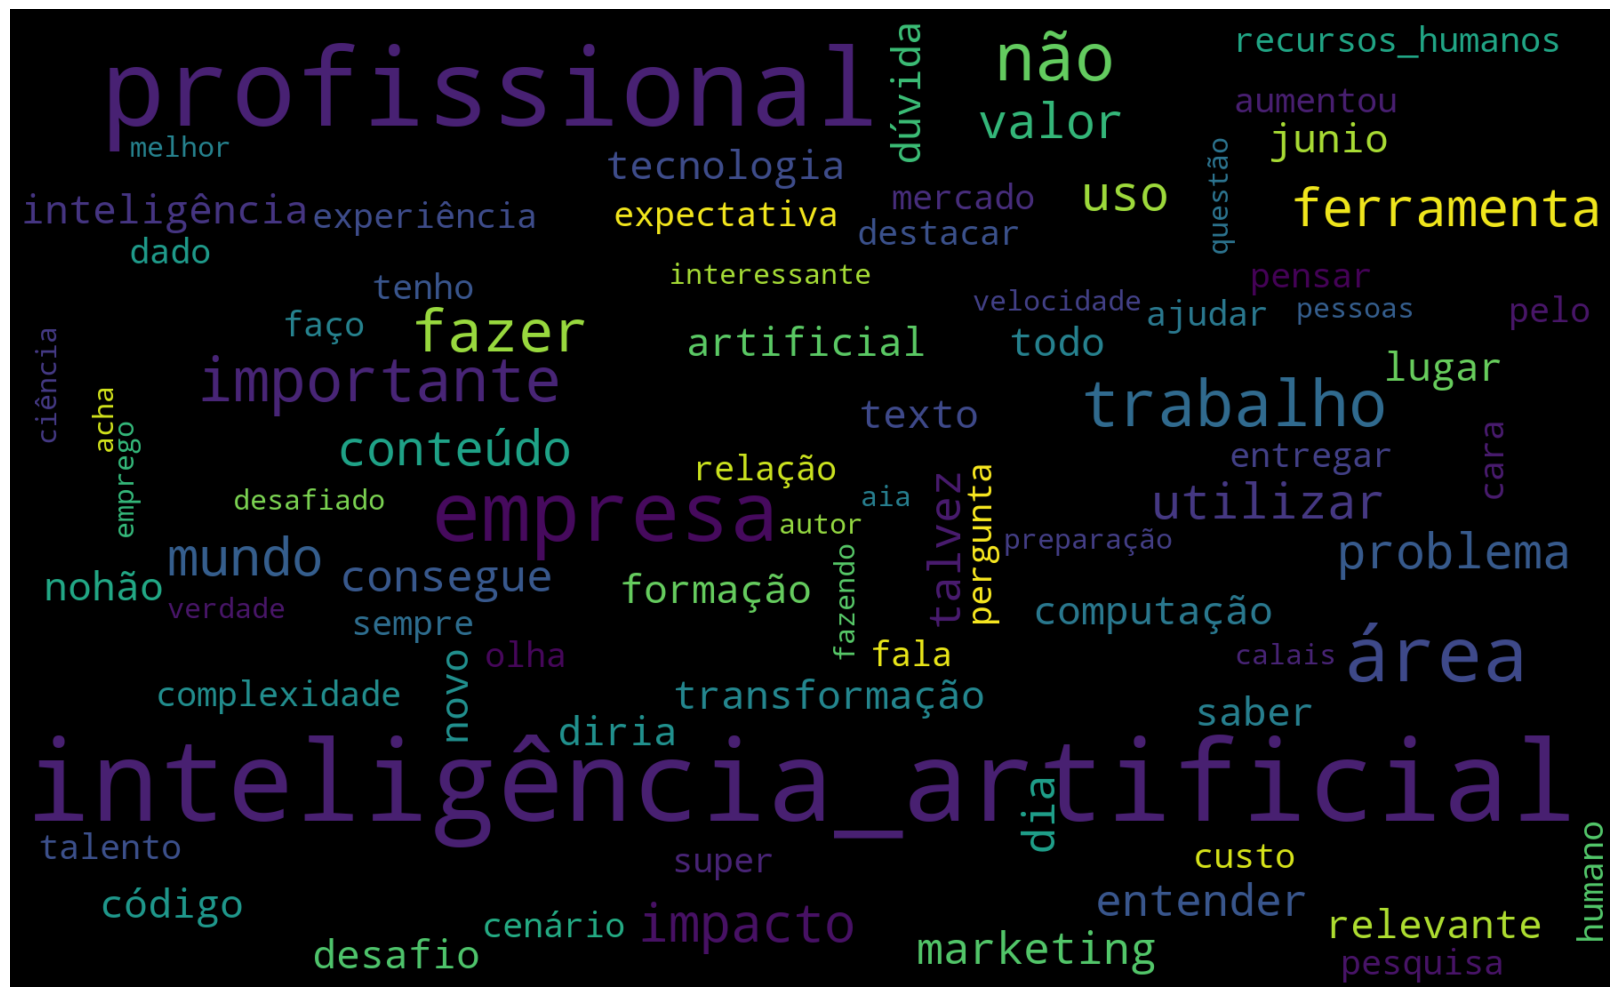

Arquivo criado: nuvem_de_palavras_ia.png
Principais termos: inteligência artificial (38), profissional (35), empresa (19), área (16), não (12), trabalho (11), importante (10), fazer (9), impacto (7), ferramenta (7), mundo (7), conteúdo (6), valor (6), uso (6), problema (6)


In [22]:
from pathlib import Path
import re
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Lê o texto enviado
path = Path("colado.txt")
text = path.read_text(encoding="utf-8").lower()

# Preserva expressões importantes como conceitos únicos
text = text.replace("inteligência artificial", "inteligência_artificial")
text = text.replace("mercado de trabalho", "mercado_trabalho")
text = text.replace("ciência de dados", "ciência_dados")
text = text.replace("recursos humanos", "recursos_humanos")

# Palavras muito comuns + vícios de linguagem da transcrição
stopwords = set("""
a o e de do da dos das em no na nos nas um uma uns umas para por com sem ao aos à às
que se sua seu suas seus este esta estes estas esse essa esses essas isso isto aquilo
como mais muito muita muitos muitas menos já ainda entre sobre ou ser foi são tem há ter
está estão estava eu ele ela eles elas nós você vocês meu minha meus minhas nosso nossa
nossos nossas mas porém porque onde quando quem qual quais assim então também só
acho sabe vai pode gente tipo vez vezes aqui ali agora né
obviamente realmente apenas mesmo mesmo assim forma parte lado coisa coisas
obrigado obrigado começar conversa falar falando exemplo dizer
""".split())

# Termos que aparecem com flexões diferentes e representam o mesmo conceito
normalizacoes = {
    "profissionais": "profissional",
    "empresas": "empresa",
    "ferrametas": "ferramenta",
    "ferramentas": "ferramenta",
    "tecnologias": "tecnologia",
    "tecnológicos": "tecnologia",
    "tecnológica": "tecnologia",
    "tecnológico": "tecnologia",
    "empregos": "emprego",
    "trabalhos": "trabalho",
    "áreas": "área",
    "decisões": "decisão",
    "problemas": "problema",
    "valores": "valor",
    "habilidades": "habilidade",
    "conteúdos": "conteúdo",
    "recursos": "recurso",
    "cursos": "curso",
    "alunos": "aluno",
    "dados": "dado",
    "ferramenta": "ferramenta",
    "inteligências": "inteligência",
}

tokens = re.findall(r"[A-Za-zÀ-ÿ_]+", text)
freq = Counter()

for token in tokens:
    if token in stopwords or len(token.replace("_", "")) < 3:
        continue
    token = normalizacoes.get(token, token)
    freq[token] += 1

# Retira alguns termos específicos da transcrição que não ajudam na visualização temática
for termo in ["pedro", "professor", "pesquisador", "brasil", "news", "ebimec", "bimec"]:
    freq.pop(termo, None)

# Gera a nuvem
wc = WordCloud(
    width=1800,
    height=1100,
    max_words=80,
    min_font_size=12,
    collocations=False,
    margin=8,
    random_state=42
).generate_from_frequencies(freq)

output = "nuvem_de_palavras_ia.png"
wc.to_file(output)

plt.figure(figsize=(16, 10))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

print(f"Arquivo criado: {output}")
print("Principais termos:", ", ".join(f"{w.replace('_', ' ')} ({n})" for w, n in freq.most_common(15)))
